# Classificazione del testo
La classificazione è uno dei problemi fondamentali dell’apprendimento supervisionato.
Consiste nell’assegnare a un elemento (detto istanza) una classe fra un insieme finito di categorie possibili, sulla base delle sue caratteristiche osservabili (dette feature o attributi).

In pratica, un modello di classificazione impara — a partire da un insieme di esempi etichettati — una regola che associa le feature di input a una o più etichette di output. Una volta addestrato, il modello può essere utilizzato per predire la classe di nuovi esempi non ancora visti.

### Classificazione binaria e non binaria

**Classificazione binaria**: 
In questo caso l’insieme delle classi possibili è costituito da due sole categorie, ad esempio “positivo/negativo”, “vero/falso”, “spam/non spam”.
Il modello impara a discriminare tra due stati o condizioni opposte.

**Classificazione non binaria (multiclasse o multilabel)**: 
Quando le classi possibili sono più di due, si parla di classificazione multiclasse o multilabel.
Esempi tipici sono il riconoscimento del tipo di animale in mammifero, uccello, pesce, ecc. o la classificazione tematica di un testo.

### Classificazione partitiva (hard) e non partitiva (soft)

Un'altra distinzione importante riguarda il modo in cui il modello assegna le classi:

**Classificazione partitiva (hard)**: 
Ogni istanza viene assegnata esattamente a una sola classe.
Il modello produce una decisione “dura”, tipicamente scegliendo la classe con la probabilità più alta.
È la forma più comune di classificazione, ad esempio nel riconoscimento di cifre o nel filtraggio spam.

**Classificazione non partitiva (soft)**: 
In questo caso, il modello non assegna una sola classe, ma fornisce una distribuzione di probabilità (o gradi di appartenenza) su tutte le classi possibili.
Questo approccio è utile quando si vuole tenere traccia dell’incertezza o quando un elemento può appartenere parzialmente a più categorie (ad esempio nei sistemi di raccomandazione o nel riconoscimento di emozioni).

## 1. Primo esempio: semplice classificazione di pseudo documenti
Per comprendere in modo concreto come funziona un sistema di classificazione supervisionata, possiamo costruire un piccolo esperimento didattico.
L’obiettivo è riconoscere la categoria di un animale (ad esempio mammifero, uccello o pesce) a partire da alcune caratteristiche testuali che lo descrivono.

**Le caratteristiche (input)**

Ogni animale è rappresentato da un breve insieme di parole chiave che ne descrivono alcune proprietà fondamentali, come ad esempio:

- pelo, piume, scaglie → tipo di rivestimento del corpo
- vola, nuota, terra → modalità di locomozione o ambiente di vita
- latte, uova → modalità di riproduzione
- zampe, becco → tratti anatomici distintivi

In questo modo, ogni animale può essere descritto come un piccolo “testo” o, più semplicemente, come un vettore di presenza/assenza delle parole del vocabolario.

**Le etichette (output)**

L’obiettivo del nostro modello è imparare ad assegnare a ciascuna descrizione una delle tre classi di output:

- mammifero
- uccello
- pesce

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import List, Dict
import torch

In [12]:
vocab: List[str] = [
    "pelo", "piume", "scaglie", "vola", "nuota",
    "terra", "latte", "uova", "zampe", "becco"
]
label_names = ["mammifero", "uccello", "pesce"]
label_to_id = {name: i for i, name in enumerate(label_names)}
id_to_label = {i: name for name, i in label_to_id.items()}
word_to_id = {w: i for i, w in enumerate(vocab)}
id_to_word = {i: w for w, i in word_to_id.items()}

#### Dati di training

In [40]:
train_examples = [
    (["pelo", "latte", "terra", "zampe"], "mammifero"),
    (["piume", "vola", "uova", "becco", "zampe"], "uccello"),
    (["scaglie", "nuota", "uova"], "pesce"),
    (["pelo", "terra", "zampe"], "mammifero"),
    (["piume", "vola", "becco"], "uccello"),
    (["scaglie", "nuota"], "pesce"),
    (["pelo", "latte"], "mammifero"),
    (["vola", "uova", "piume"], "uccello"),
    (["nuota", "scaglie", "uova"], "pesce"),
    (["pelo", "uova", "zampe"], "mammifero"),
    (["piume", "terra", "becco", "zampe"], "uccello"),
    (["scaglie", "terra", "nuota"], "pesce"),
]
test_examples = [
    (["nuota", "latte"], "mammifero"),
    (["piume", "terra", "uova", "becco"], "uccello"),
    (["uova", "latte", "terra", "nuota"], "pesce"),
]

**Preparazione dei dati**

In [14]:
from torch.utils.data import TensorDataset, DataLoader

In [41]:
X = torch.zeros((len(train_examples), len(vocab)), dtype=torch.float32)
X_test = torch.zeros((len(test_examples), len(vocab)), dtype=torch.float32)
y = torch.zeros((len(train_examples), len(label_names)))
y_test = torch.zeros((len(test_examples), len(label_names)))
for i, (data, label) in enumerate(train_examples):
    for word in data:
        X[i,word_to_id[word]] = 1.0
    y[i,label_to_id[label]] = 1.0
for i, (data, label) in enumerate(test_examples):
    for word in data:
        X_test[i,word_to_id[word]] = 1.0
    y_test[i,label_to_id[label]] = 1.0

In [18]:
pd.DataFrame(X, columns=vocab)

,pelo,piume,scaglie,vola,nuota,terra,latte,uova,zampe,becco
0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0
1,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0
2,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
5,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
6,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
7,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
8,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
9,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0


In [20]:
pd.DataFrame(y, columns=label_names)

,mammifero,uccello,pesce
0,1.0,0.0,0.0
1,0.0,1.0,0.0
2,0.0,0.0,1.0
3,1.0,0.0,0.0
4,0.0,1.0,0.0
5,0.0,0.0,1.0
6,1.0,0.0,0.0
7,0.0,1.0,0.0
8,0.0,0.0,1.0
9,1.0,0.0,0.0


**Batch**

Un batch è un pacchetto dei dati di training. L'idea è che il ciclo di apprendimento non preveda di aggiornare i parametri osservazione per osservazione, ma osservando una media dell'errore per interi "pacchetti" di dati. I vantaggi sono:
1. **Efficienza computazionale**: le GPU sono ottimizzate per calcoli paralleli massicci (algebra lineare). Lavorare su più campioni tutti insieme (un batch) è quindi molto più veloce che osservare i campioni uno alla volta.
2. **Stabilità dell'apprendimento**: aggiornare la rete dopo ogni singolo campione (che potrebbe essere un outlier o un dato anomalo) rende l'addestramento "rumoroso" e instabile. Calcolare l'aggiornamento sulla media di un batch "smussa" queste variazioni, fornendo una direzione di apprendimento più stabile e affidabile.

In [21]:
BATCH_SIZE = 2
y_correct_labels = y.argmax(dim=1)
dataset = TensorDataset(X, y_correct_labels)
training_set = DataLoader(dataset=dataset, batch_size=BATCH_SIZE, shuffle=True)

### La rete neurale
Utilizziamo in prima battuta una rete che trasforma direttamente l'input in output

In [22]:
from nnet import SimpleLinearNetwork
import pandas as pd 

In [23]:
input_size = len(vocab)
output_size = len(label_names)

model = SimpleLinearNetwork(input_size=input_size, num_classes=output_size)

model.eval()

prediction = model(X)

print(f"Dimensione dell'output: {prediction.shape}")
print(f"Esempio sul primo animale: {prediction[0]}")
print(f"Da log prob a probabilità: {torch.exp(prediction[0])}")

Dimensione dell'output: torch.Size([12, 3])
Esempio sul primo animale: tensor([-0.9110, -1.2360, -1.1798], grad_fn=<SelectBackward0>)
Da log prob a probabilità: tensor([0.4021, 0.2905, 0.3073], grad_fn=<ExpBackward0>)


### Visualizzazione dell'output

In [24]:
def readable_probs(y_pred):
    p = torch.exp(y_pred)
    out = pd.DataFrame(p.detach().numpy(), columns=[id_to_label[i] for i in range(p.shape[1])])
    return out 

In [25]:
y_read = readable_probs(prediction)
y_read

,mammifero,uccello,pesce
0,0.402124,0.290545,0.307331
1,0.299046,0.267582,0.433372
2,0.311717,0.344054,0.344229
3,0.386383,0.267091,0.346526
4,0.339221,0.293072,0.367707
5,0.381297,0.314859,0.303844
6,0.338030,0.442287,0.219684
7,0.239262,0.393315,0.367423
8,0.311717,0.344054,0.344229
9,0.301565,0.390969,0.307466


### Valutazione

In [26]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [27]:
# Selezioniamo la classe più probabile
y_pred = prediction.argmax(dim=1).detach().numpy()
y_pred_labels = [id_to_label[x] for x in y_pred]
y_true = y.argmax(dim=1).detach().numpy()
y_true_labels = [id_to_label[x] for x in y_true]

In [31]:
y_pred_labels[:4]

['mammifero', 'pesce', 'pesce', 'mammifero']

In [32]:
y_true_labels[:4]

['mammifero', 'uccello', 'pesce', 'mammifero']

In [33]:
print(classification_report(y_true=y_true_labels, y_pred=y_pred_labels, zero_division=0))

              precision    recall  f1-score   support

   mammifero       0.50      0.50      0.50         4
       pesce       0.40      0.50      0.44         4
     uccello       0.33      0.25      0.29         4

    accuracy                           0.42        12
   macro avg       0.41      0.42      0.41        12
weighted avg       0.41      0.42      0.41        12



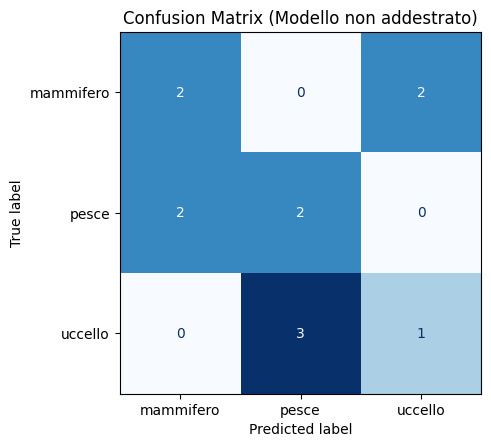

In [34]:
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_true=y_true_labels, y_pred=y_pred_labels,
#    display_labels=display_labels,
    cmap=plt.cm.Blues, normalize=None, ax=ax,
    colorbar=False
)
ax.set_title("Confusion Matrix (Modello non addestrato)")
plt.tight_layout()
plt.show()

## Alleniamo il modello

In [35]:
import torch.nn 
import torch.optim

In [36]:
criterion = torch.nn.NLLLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)

EPOCHS = 150
loss_history = []
for epoch in range(EPOCHS):
    running_loss = 0
    for x_batch, y_batch in training_set:
        model.train()
        optimizer.zero_grad()
        log_probs = model(x_batch)
        loss = criterion(log_probs, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    avg_loss = running_loss / len(training_set)
    loss_history.append(avg_loss)
    if (epoch + 1) % 10 == 0 or epoch == 0 or epoch == EPOCHS - 1:
        print(f"Epoca [{epoch+1: >3}/{EPOCHS}], Loss media: {avg_loss:.6f}")


Epoca [  1/150], Loss media: 1.124112
Epoca [ 10/150], Loss media: 0.449624
Epoca [ 20/150], Loss media: 0.241660
Epoca [ 30/150], Loss media: 0.159641
Epoca [ 40/150], Loss media: 0.117867
Epoca [ 50/150], Loss media: 0.092818
Epoca [ 60/150], Loss media: 0.076471
Epoca [ 70/150], Loss media: 0.064876
Epoca [ 80/150], Loss media: 0.056204
Epoca [ 90/150], Loss media: 0.049658
Epoca [100/150], Loss media: 0.044382
Epoca [110/150], Loss media: 0.040176
Epoca [120/150], Loss media: 0.036659
Epoca [130/150], Loss media: 0.033693
Epoca [140/150], Loss media: 0.031211
Epoca [150/150], Loss media: 0.029022


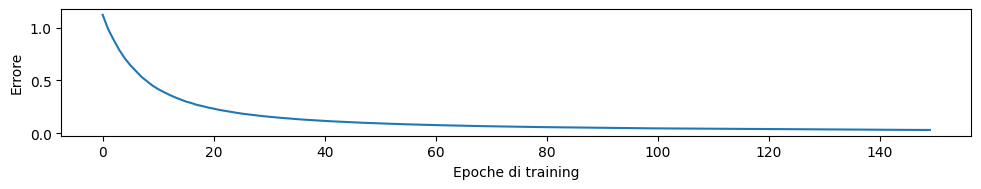

In [37]:
fig, ax = plt.subplots(figsize=(10, 2))
ax.plot(loss_history)
ax.set_xlabel("Epoche di training")
ax.set_ylabel("Errore")
plt.tight_layout()
plt.show()

### Valutazione del modello allenato

In [38]:
model.eval()
prediction = model(X)

y_pred = prediction.argmax(dim=1).detach().numpy()
y_pred_labels = [id_to_label[x] for x in y_pred]
y_true = y.argmax(dim=1).detach().numpy()
y_true_labels = [id_to_label[x] for x in y_true]

print(classification_report(y_true=y_true_labels, y_pred=y_pred_labels, zero_division=0))

              precision    recall  f1-score   support

   mammifero       1.00      1.00      1.00         4
       pesce       1.00      1.00      1.00         4
     uccello       1.00      1.00      1.00         4

    accuracy                           1.00        12
   macro avg       1.00      1.00      1.00        12
weighted avg       1.00      1.00      1.00        12



In [42]:
model.eval()
prediction_test = model(X_test)

y_pred_test = prediction_test.argmax(dim=1).detach().numpy()
y_pred_test_labels = [id_to_label[x] for x in y_pred_test]
y_true_test = y_test.argmax(dim=1).detach().numpy()
y_true_test_labels = [id_to_label[x] for x in y_true_test]

print(classification_report(y_true=y_true_test_labels, y_pred=y_pred_test_labels, zero_division=0))

              precision    recall  f1-score   support

   mammifero       0.00      0.00      0.00         1
       pesce       0.50      1.00      0.67         1
     uccello       1.00      1.00      1.00         1

    accuracy                           0.67         3
   macro avg       0.50      0.67      0.56         3
weighted avg       0.50      0.67      0.56         3



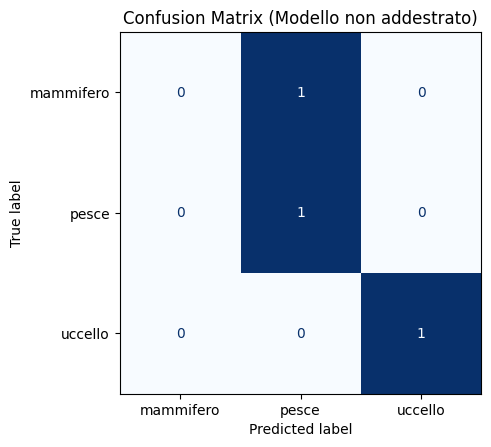

In [43]:
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_true=y_true_test_labels, y_pred=y_pred_test_labels,
#    display_labels=display_labels,
    cmap=plt.cm.Blues, normalize=None, ax=ax,
    colorbar=False
)
ax.set_title("Confusion Matrix (Modello non addestrato)")
plt.tight_layout()
plt.show()

## Cosa impara la macchina?

In [44]:
params = model.linear_layer.weight
print(f"Dimensione dei parametri: {params.shape}")
print(params)

def get_word_vector(word, params):
    wid = word_to_id[word]
    v = params[:,wid].detach().numpy()
    return v 

Dimensione dei parametri: torch.Size([3, 10])
Parameter containing:
tensor([[ 1.6776, -1.0272, -0.6655, -0.4411, -1.0845,  0.0509,  0.9444, -0.2574,
          0.7521, -0.7011],
        [-0.8349,  1.6870, -0.9123,  1.0931, -0.7439, -0.0993, -0.1837, -0.0325,
         -0.0098,  0.9150],
        [-0.7563, -0.5561,  1.2883, -0.4158,  1.5070,  0.1145, -0.2484,  0.1446,
         -0.8251, -0.4611]], requires_grad=True)


In [45]:
vocab_vectors = np.array([get_word_vector(w, params) for w in vocab])
V = pd.DataFrame(vocab_vectors, index=vocab)

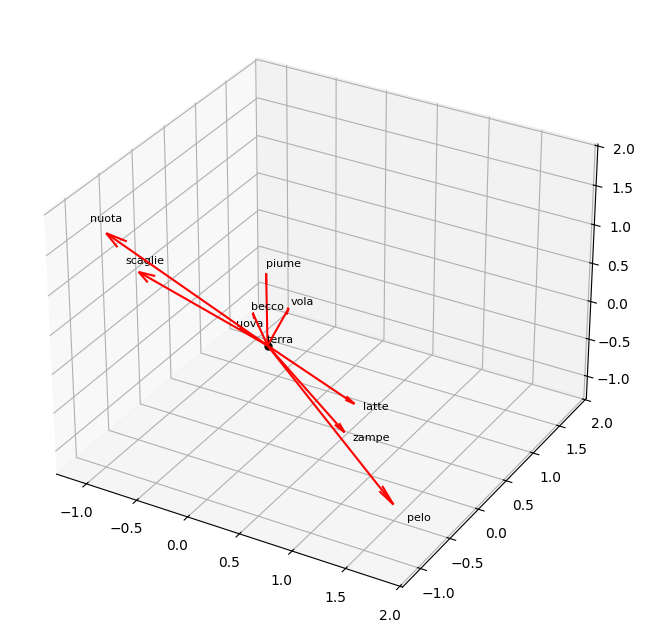

In [46]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
for w, row in V.iterrows():
    v = row.values
    ax.quiver(0, 0, 0, v[0], v[1], v[2], 
                  arrow_length_ratio=0.1,
                  color='red')
    ax.text(v[0] * 1.1, v[1] * 1.1, v[2] * 1.1, 
                w, 
                color='black', fontsize=8)
ax.plot([0], [0], [0], 'ko', markersize=5)
max_val = V.max().max() * 1.2
min_val = V.min().min() * 1.2
ax.set_xlim([min_val, max_val])
ax.set_ylim([min_val, max_val])
ax.set_zlim([min_val, max_val])
    
plt.show()

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
S = pd.DataFrame(cosine_similarity(V, V), index=vocab, columns=vocab)
S 

In [ ]:
S.loc['pelo'].sort_values(ascending=False)